<a href="https://colab.research.google.com/github/sk-shahsi/ML_Model/blob/master/Logistic_Regretion_pract.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
heart=pd.read_csv('/content/heart.csv')

In [ ]:
heart

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [ ]:
heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
heart.shape

(303, 14)

In [ ]:
heart.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [ ]:
heart.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
heart.duplicated().sum()

np.int64(1)

In [ ]:
heart[heart.duplicated()] # printing all duplicated row

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
164,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1


In [ ]:
heart.drop_duplicates(inplace=True)

In [ ]:
heart.duplicated().sum()

np.int64(0)

**Outliers Removels**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

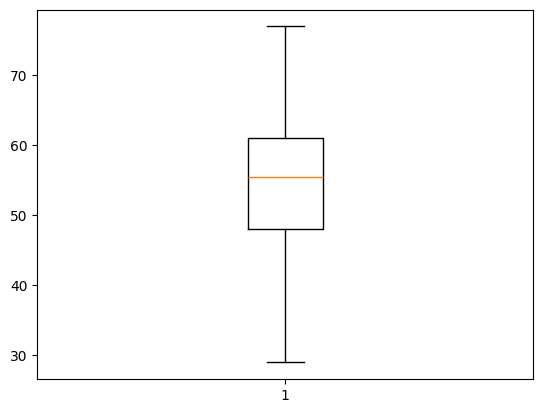

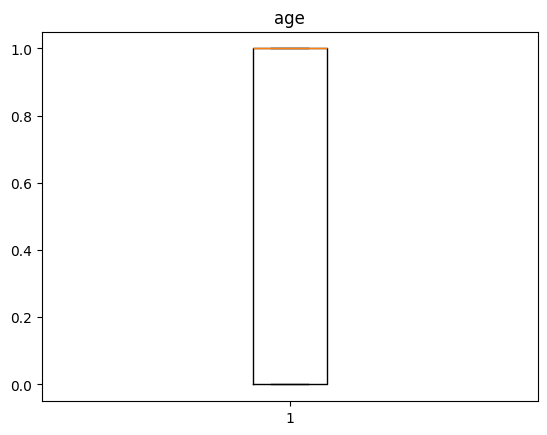

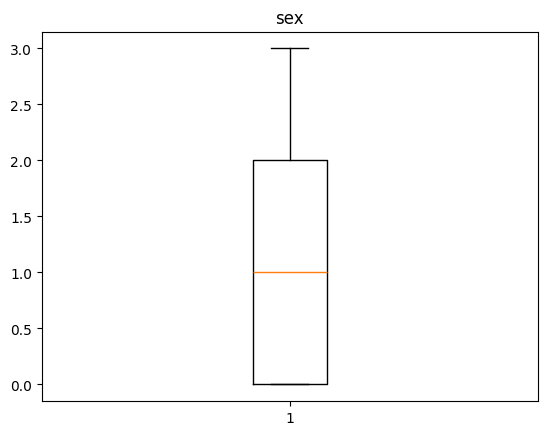

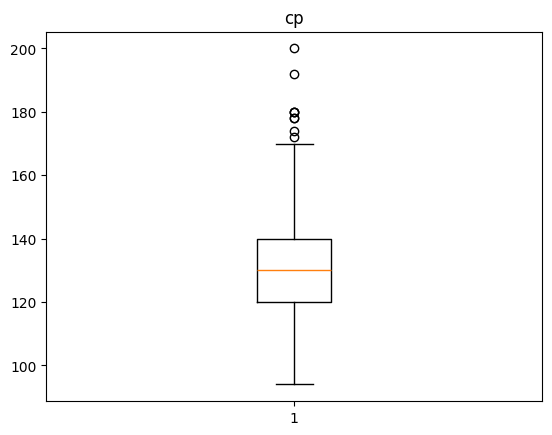

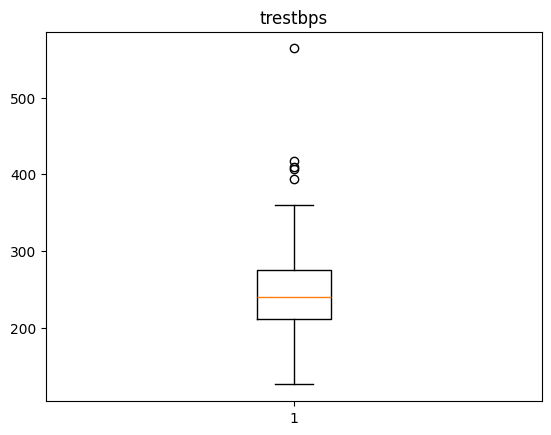

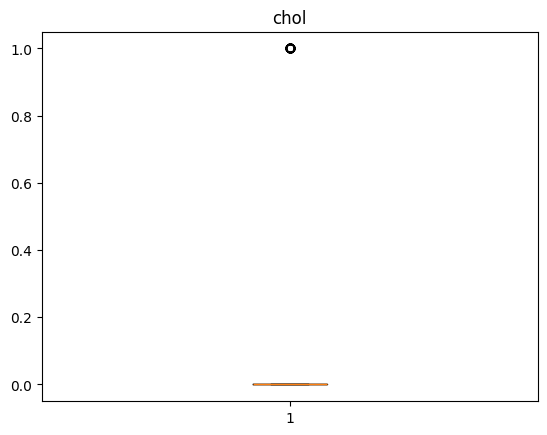

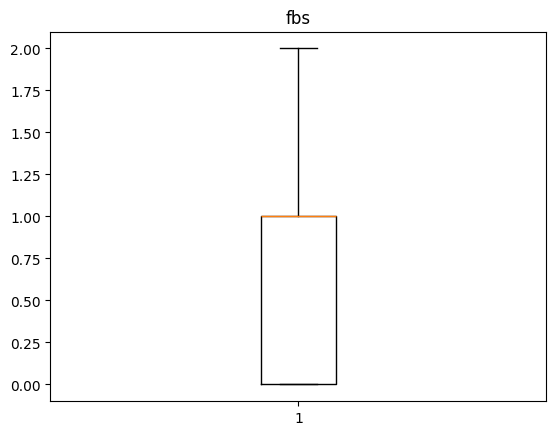

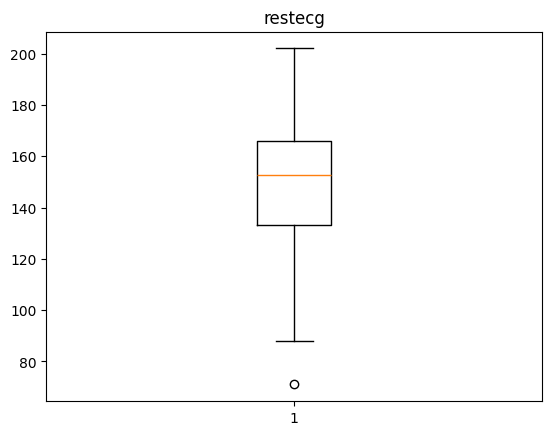

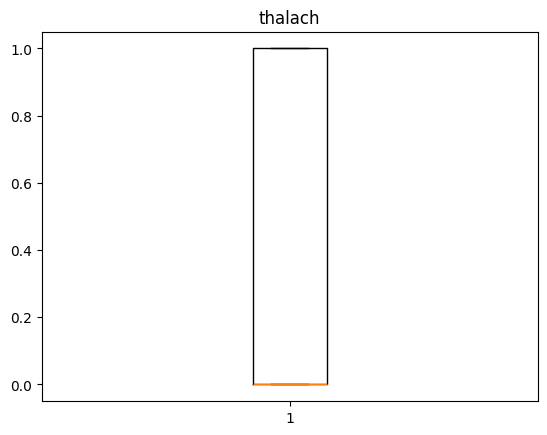

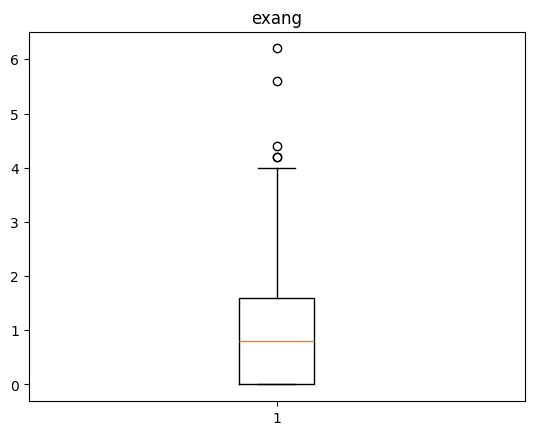

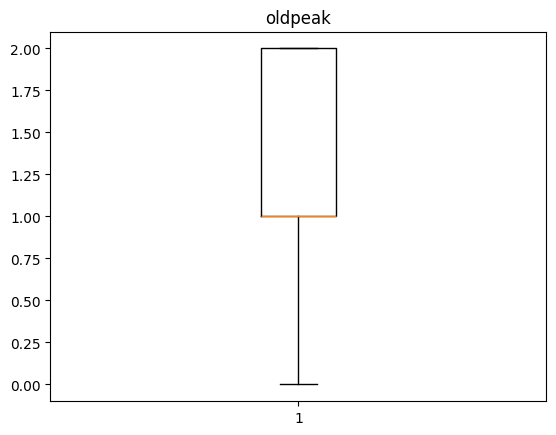

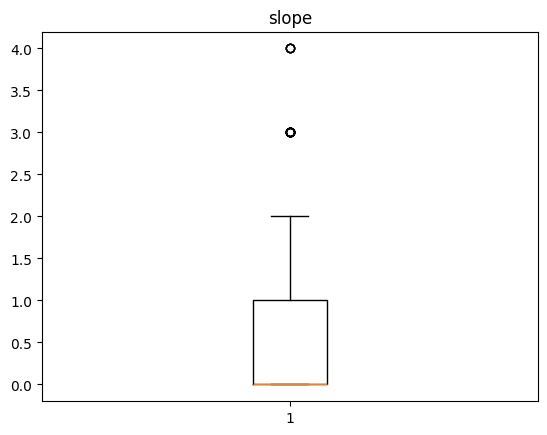

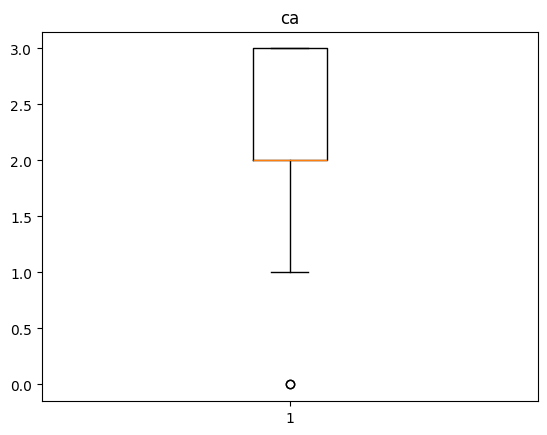

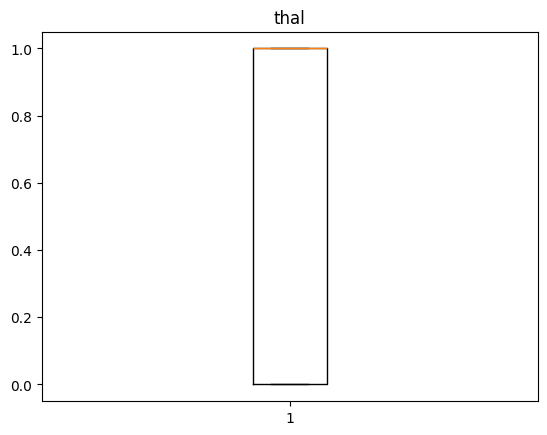

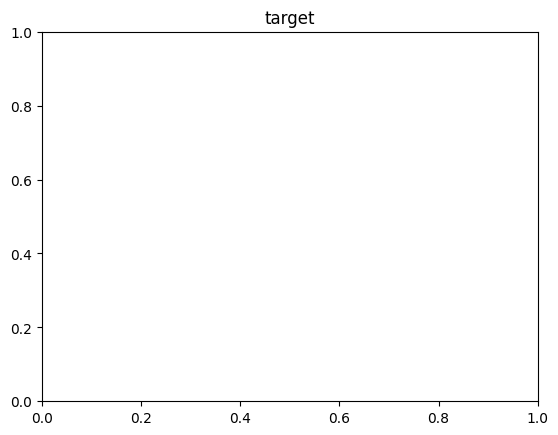

In [ ]:
for i in heart.columns:
  if heart[i].dtype !='object':
    plt.boxplot(heart[i])
    plt.show()
    plt.title(i)

In [ ]:
heart.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
for i in heart.columns:
  Q1=heart[i].quantile(0.25)
  Q3=heart[i].quantile(0.75)

  IQR=Q3-Q1
  lb = Q1-1.5*IQR
  ub = Q3+1.5*IQR

  heart = heart[(heart[i]>=lb) & (heart[i]<=ub)]

In [ ]:
heart.shape

(228, 14)

**Machine Learning Processing**

In [ ]:
x= heart.drop(columns='target')
y = heart['target']

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# split the data in to train and test
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=100)

**Standarization / Scaling of the data**

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

** Applying Logistic Regression on the data**

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model = LogisticRegression()
model.fit(x_train_scaled,y_train)

LogisticRegression()

In [ ]:
model.coef_

array([[ 0.30399547, -0.948296  ,  0.82151121, -0.37145731, -0.18314074,
         0.        ,  0.43123184,  0.51289703, -0.12307467, -0.52244246,
         0.55582937, -1.23926232, -1.02828391]])

In [ ]:
model.intercept_

array([0.37419847])

In [ ]:
y_pred = model.predict(x_test_scaled)

In [ ]:
y_pred

array([1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1,
       0, 1])

In [ ]:
probs=model.predict_proba(x_test_scaled)

In [ ]:
probs

array([[0.13028478, 0.86971522],
       [0.07547323, 0.92452677],
       [0.99096828, 0.00903172],
       [0.80199262, 0.19800738],
       [0.87548783, 0.12451217],
       [0.86028221, 0.13971779],
       [0.00633808, 0.99366192],
       [0.90314009, 0.09685991],
       [0.02225988, 0.97774012],
       [0.03446289, 0.96553711],
       [0.62542777, 0.37457223],
       [0.7765124 , 0.2234876 ],
       [0.00341281, 0.99658719],
       [0.00878494, 0.99121506],
       [0.8645028 , 0.1354972 ],
       [0.36936109, 0.63063891],
       [0.01930394, 0.98069606],
       [0.13965754, 0.86034246],
       [0.0023377 , 0.9976623 ],
       [0.37634955, 0.62365045],
       [0.19991268, 0.80008732],
       [0.03007574, 0.96992426],
       [0.47837254, 0.52162746],
       [0.06283374, 0.93716626],
       [0.03111788, 0.96888212],
       [0.96642982, 0.03357018],
       [0.98178   , 0.01822   ],
       [0.83888913, 0.16111087],
       [0.68386569, 0.31613431],
       [0.99416668, 0.00583332],
       [0.

In [ ]:
accuracy_score(y_test, y_pred)

NameError: name 'accuracy_score' is not defined

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_score(y_test, y_pred)

0.8478260869565217